In [1]:
#2.1
import numpy as np

a = np.array([2, -1, 3])
b = np.array([1, 4, -2])

A = np.array([[1, 0, 2],
              [-1, 3, 1]])
B = np.array([[2, 1],
              [0, -1],
              [3, 2]])

dot_product = np.dot(a, b)
print("1. 向量点积 a·b =")
print(dot_product)

matrix_product = A @ B 
result_shape = matrix_product.shape
print("\n2. 矩阵乘法 A × B =")
print(matrix_product)
print(f"   结果矩阵的形状 = {result_shape}")

frobenius_norm_a = np.linalg.norm(a)
print("\n3. 向量 a 的 Frobenius 范数 =")
print(frobenius_norm_a)

1. 向量点积 a·b =
-8

2. 矩阵乘法 A × B =
[[ 8  5]
 [ 1 -2]]
   结果矩阵的形状 = (2, 2)

3. 向量 a 的 Frobenius 范数 =
3.7416573867739413


In [4]:
#2.2
import torch

X = torch.randn(3, 4)
Y = torch.ones(4, 2)
Z = torch.mm(X, Y)
element = Z[0, 1]
row_2 = Z[1, :]
norm = torch.linalg.matrix_norm(Z)

print(element)
print(row_2)
print(norm)

tensor(-1.3159)
tensor([4.0991, 4.0991])
tensor(7.9844)


In [5]:
#3.1
p_d = 0.001
p_pos_given_d = 0.99
p_pos_given_not_d = 0.02
p_not_d = 1.0 - p_d
p_pos = (p_pos_given_d * p_d) + (p_pos_given_not_d * p_not_d)
p_d_given_pos = (p_pos_given_d * p_d) / p_pos
print(p_d_given_pos)

0.047210300429184546


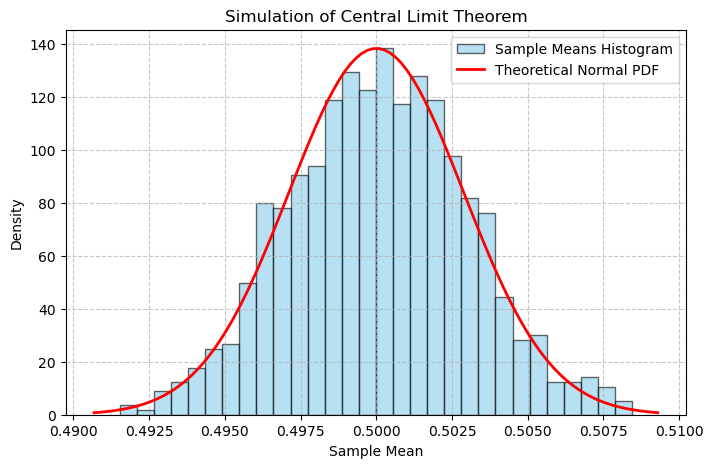

1000个均值的实际方差: 0.0000087113
理论方差 (1/(12*10000)): 0.0000083333


In [1]:
#3.2

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm


n = 10000
m = 1000


samples = np.random.uniform(0, 1, size=(m, n))

means = np.mean(samples, axis=1)

plt.figure(figsize=(8, 5))

plt.hist(means, bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Sample Means Histogram')

mu_theoretical = 0.5
sigma2_theoretical_single = 1 / 12

mu_means = mu_theoretical
sigma2_means = sigma2_theoretical_single / n
std_means = np.sqrt(sigma2_means)

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu_means, std_means)

plt.plot(x, p, 'r-', linewidth=2, label='Theoretical Normal PDF')

plt.title('Simulation of Central Limit Theorem')
plt.xlabel('Sample Mean')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

actual_variance = np.var(means, ddof=1) # 样本方差
print(f"1000个均值的实际方差: {actual_variance:.10f}")
print(f"理论方差 (1/(12*10000)): {sigma2_means:.10f}")

In [2]:
#4.1
import sympy as sp

w1, w2 = sp.symbols('w1 w2')
x1, x2, y = 2, 1, 3
z = (w1*x1 + w2*x2 - y)**2

dz_dw1 = sp.diff(z, w1)
dz_dw2 = sp.diff(z, w2)

print(dz_dw1)
print(dz_dw2)

grad_w1 = dz_dw1.subs({w1: 0.5, w2: 1})
grad_w2 = dz_dw2.subs({w1: 0.5, w2: 1})

print(grad_w1)
print(grad_w2)

8*w1 + 4*w2 - 12
4*w1 + 2*w2 - 6
-4.00000000000000
-2.00000000000000


In [3]:
#4.2
import torch

x = 2.0
w1 = 1.5
w2 = 0.5

a = x * w1
b = a + w2
L = b ** 2

dL_db = 2 * b
dL_da = dL_db * 1
dL_dw2 = dL_db * 1
dL_dw1 = dL_da * x

print(L)
print(dL_dw1)
print(dL_dw2)

x_t = torch.tensor(x)
w1_t = torch.tensor(w1, requires_grad=True)
w2_t = torch.tensor(w2, requires_grad=True)

a_t = x_t * w1_t
b_t = a_t + w2_t
L_t = b_t ** 2

L_t.backward()

print(L_t.item())
print(w1_t.grad.item())
print(w2_t.grad.item())

12.25
14.0
7.0
12.25
14.0
7.0


In [6]:
#5.1
import sympy as sp

w, b, n, i = sp.symbols('w b n i')
x = sp.IndexedBase('x')
y = sp.IndexedBase('y')

L = (1/n) * sp.Sum((y[i] - (w*x[i] + b))**2, (i, 1, n))

dL_dw = sp.diff(L, w)
dL_db = sp.diff(L, b)

print(dL_dw)
print(dL_db)

Sum(-2*(-b - w*x[i] + y[i])*x[i], (i, 1, n))/n
Sum(2*b + 2*w*x[i] - 2*y[i], (i, 1, n))/n


In [7]:
#5.2
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

digits = load_digits()
X = digits.data
y = digits.target

num_classes = len(np.unique(y))
y_one_hot = np.eye(num_classes)[y]

X_train, X_test, y_train, y_test = train_test_split(X, y_one_hot, test_size=0.2, random_state=42)

def softmax(Z):
    exp_Z = np.exp(Z - np.max(Z, axis=1, keepdims=True))
    return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

def cross_entropy_loss(Y_hat, Y):
    m = Y.shape[0]
    return -np.sum(Y * np.log(Y_hat + 1e-9)) / m

W = np.random.randn(X_train.shape[1], num_classes) * 0.01
b = np.zeros(num_classes)

epochs = 50
batch_size = 32
lr = 0.1
m = X_train.shape[0]

for epoch in range(epochs):
    indices = np.arange(m)
    np.random.shuffle(indices)
    X_train_shuffled = X_train[indices]
    y_train_shuffled = y_train[indices]
    
    for i in range(0, m, batch_size):
        X_batch = X_train_shuffled[i:i+batch_size]
        y_batch = y_train_shuffled[i:i+batch_size]
        
        batch_m = X_batch.shape[0]
        
        Z = np.dot(X_batch, W) + b
        A = softmax(Z)
        
        loss = cross_entropy_loss(A, y_batch)
        
        dZ = A - y_batch
        dW = np.dot(X_batch.T, dZ) / batch_m
        db = np.sum(dZ, axis=0) / batch_m
        
        W -= lr * dW
        b -= lr * db

Z_test = np.dot(X_test, W) + b
A_test = softmax(Z_test)
predictions = np.argmax(A_test, axis=1)
labels = np.argmax(y_test, axis=1)
accuracy = np.mean(predictions == labels)

print(accuracy)

0.9666666666666667


In [9]:
#6.1
import sympy as sp

mu = sp.Symbol('mu', real=True)
sigma2 = sp.Symbol('sigma2', real=True, positive=True)
n = sp.Symbol('n', integer=True, positive=True)
i = sp.Symbol('i', integer=True, positive=True)
x = sp.IndexedBase('x')

pdf = (1 / sp.sqrt(2 * sp.pi * sigma2)) * sp.exp(-(x[i] - mu)**2 / (2 * sigma2))

L = sp.Product(pdf.subs(i, sp.Symbol('j')), (sp.Symbol('j'), 1, n))

log_L = sp.Sum(sp.log(pdf), (i, 1, n))
log_L_expanded = sp.expand_log(log_L, force=True)

# Expand and evaluate the derivative to pull mu out of the sum
d_log_L_d_mu = sp.diff(log_L_expanded, mu).expand().doit()
mu_hat = sp.solve(d_log_L_d_mu, mu)[0]

# Expand and evaluate the derivative to pull sigma2 out of the sum
d_log_L_d_sigma2 = sp.diff(log_L_expanded, sigma2).expand().doit()
sigma2_hat = sp.solve(d_log_L_d_sigma2, sigma2)[0]
sigma2_hat = sigma2_hat.subs(mu, mu_hat)

print("mu_hat:", mu_hat)
print("sigma2_hat:", sigma2_hat)

mu_hat: Sum(x[i], (i, 1, n))/n
sigma2_hat: -sqrt(n)*sqrt(n - 8*Sum(x[i]**2/(2*sigma2**2), (i, 1, n))*Sum(x[i], (i, 1, n))**2/n**2 - 8*Sum(-x[i]*Sum(x[i], (i, 1, n))/(n*sigma2**2), (i, 1, n))*Sum(x[i], (i, 1, n))**2/n**2)/(4*(Sum(x[i]**2/(2*sigma2**2), (i, 1, n)) + Sum(-x[i]*Sum(x[i], (i, 1, n))/(n*sigma2**2), (i, 1, n)))) + n/(4*(Sum(x[i]**2/(2*sigma2**2), (i, 1, n)) + Sum(-x[i]*Sum(x[i], (i, 1, n))/(n*sigma2**2), (i, 1, n))))


In [ ]:
from IPython.display import Markdown, display

def generate_answer():
    return r"""

## 1. 似然函数

$$
L(\mu, \sigma^2) = (2\pi\sigma^2)^{-n/2} \exp\left(-\frac{1}{2\sigma^2}\sum (x_i-\mu)^2\right)
$$

## 2. 参数估计

$$
\hat{\mu} = \frac{1}{n}\sum x_i
$$

$$
\hat{\sigma}^2 = \frac{1}{n}\sum (x_i-\hat{\mu})^2
$$
"""

display(Markdown(generate_answer()))


# 最大似然估计解答

## 1. 似然函数

$$
L(\mu, \sigma^2) = (2\pi\sigma^2)^{-n/2} \exp\left(-\frac{1}{2\sigma^2}\sum (x_i-\mu)^2\right)
$$

## 2. 参数估计

$$
\hat{\mu} = \frac{1}{n}\sum x_i
$$

$$
\hat{\sigma}^2 = \frac{1}{n}\sum (x_i-\hat{\mu})^2
$$


测试集分类准确率: 100.00%


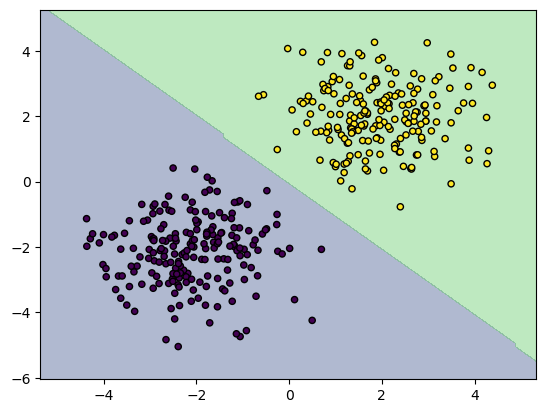

In [12]:
#6.2
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
X1 = np.random.randn(200, 2) + np.array([2, 2])
X2 = np.random.randn(200, 2) + np.array([-2, -2])
X = np.vstack((X1, X2))
Y = np.hstack((np.ones(200), np.zeros(200)))

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def bce_loss(y_true, y_pred):
    return -np.mean(y_true * np.log(y_pred + 1e-9) + (1 - y_true) * np.log(1 - y_pred + 1e-9))

w = np.zeros(2)
b = 0.0
lr = 0.1
epochs = 1000

for _ in range(epochs):
    z = np.dot(X, w) + b
    y_pred = sigmoid(z)
    dw = np.dot(X.T, (y_pred - Y)) / len(Y)
    db = np.mean(y_pred - Y)
    w -= lr * dw
    b -= lr * db

X1_test = np.random.randn(50, 2) + np.array([2, 2])
X2_test = np.random.randn(50, 2) + np.array([-2, -2])
X_test = np.vstack((X1_test, X2_test))
Y_test = np.hstack((np.ones(50), np.zeros(50)))

y_test_pred = sigmoid(np.dot(X_test, w) + b) >= 0.5
acc = np.mean(y_test_pred == Y_test)
print(f"测试集分类准确率: {acc * 100:.2f}%")

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
Z = sigmoid(np.dot(np.c_[xx.ravel(), yy.ravel()], w) + b) >= 0.5
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.4)
plt.scatter(X[:, 0], X[:, 1], c=Y, s=20, edgecolor='k')
plt.show()